# Реализация модели для Классификации+Локализации
В этом практическом уроке мы реализуем классификацию и локализацю одного объекта на изображении с помощью свёрточной нейронной сети. Локазизация объекта будет задаваться ограничивающим прямоугольником (4 числа). В качестве данных будем использовать датасает MNIST. Однако, потребуется его модификация, так как исходный датасет предназначен лишь для задачи классификации. Поэтому мы синтезируем новый датасет, в котором будем помещать цифру на некоторый холст бОльшего размера, где её и нужно будет "локализовать".

### Загрузка необходимых библиотек
Здесь мы загружаем различне библиотеки, включая TensoFlow.


In [1]:
import random
import numpy as np
import skimage.filters

%matplotlib inline
import matplotlib.pyplot as plt

import tensorflow as tf
#tf.enable_eager_execution()
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


# Подготовка датасета

### Загрузка оригинального датасета MNIST
Загружаем датасет MNIST (train и test) и приводим данные к удобному формату:
* Размер: (N, 28, 28, 1), где N - количество образцов в подвыборке
* Значения интесивности: float32 в диапазоне [0, 1]

In [2]:
(train_x, train_y), (test_x, test_y) = tf.keras.datasets.mnist.load_data()

train_x = train_x.reshape(-1, 28, 28, 1).astype(np.float32) / 255.
test_x = test_x.reshape(-1, 28, 28, 1).astype(np.float32) / 255.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Подготовка фона для для новых изображений

Нам предстоит синтезировать новый датасет, который будет состоять из изображений бОльшего размера, чем 28x28. На каждом таком новом изображении где-то будет находиться цифра из MNIST, которую нужно будет "локализовать".

Мы могли бы сделать фон таких новых изображений просто чёрным, однако это не интересно. Поэтому мы возьмем в качестве фона некоторый сгенерированный шум. Для синтеза такого фона сгенерируем случайный равномерный шум и "размоем" его с помощью фильтра Гаусса. Сразу синтезируем одно большое изображение 1000x1000 из которого будем случайным образом брать кусочки для фона очрендного образца.



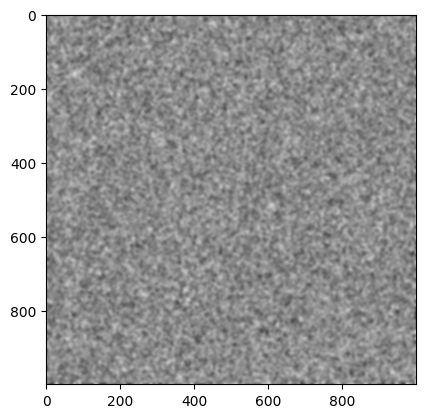

In [3]:
bg_source = np.random.rand(1000, 1000, 1).astype(np.float32)
bg_source = skimage.filters.gaussian(bg_source, 4)
bg_source = (bg_source - np.min(bg_source))/(np.max(bg_source) - np.min(bg_source))
bg_source = np.clip(bg_source, 0, 1)

plt.imshow(bg_source[..., 0], 'gray')

### Функция для конвертации MNIST в датасет для локализации
Реализуем функцию `convert_to_loc_ds`, в которую передается подвыборка (train или test) картинок из MNIST (x) и правильных классификационных ответов (y). Задача функции сгенерировать новый датасет, состоящий из картинок размера `new_size`. Для каждой новой картинки мы сначала возьмем случайный кусочек фона из `bg_source`, а затем поместим цифру из MNIST на случайное место в новой картинке.

В качестве Ground-Truth (истинных) данных для одного образца будем использовать матрицу размером 10x5, где 10 = количество классов, а 5 = 1+4 (вероятность данного класса + прямоугольник (бокс), соответствующий данному классу). Для истинного класса вероятность будет равна 1, а координаты прямоугольника соовтетствовать тому случайному месту, куда мы поместили цифру из MNIST. Для остальных классов вероятность будет равна 0, а в качестве прямоугольника мы возьмём невозможный прямоуголник с координатами [-1, -1, -1, -1] -- это будет дополниеьльный сигнал для модели, что на картинке нет соответствующего класса.

Кроме того, координаты прямоуголника обычно нормализуют относительно размеров картинки (`new_size`).

In [4]:
def convert_to_loc_ds(x, y, bg_source, new_size):
    x_new = np.zeros((x.shape[0], new_size[0], new_size[1], 1), dtype=np.float32)
    y_new = np.zeros((y.shape[0], 10, 5), dtype=np.float32)
    y_new[:, :, 1:] = -1

    rh = float(x.shape[1]) / new_size[0]
    rw = float(x.shape[2]) / new_size[1]

    for i in range(x.shape[0]):
        oh = random.randint(0, bg_source.shape[0] - new_size[0])
        ow = random.randint(0, bg_source.shape[1] - new_size[1])
        x_new[i] = bg_source[oh:oh+new_size[0], ow:ow+new_size[1], :]
        oh = random.randint(0, x_new[i,...].shape[0] - x[i].shape[0])
        ow = random.randint(0, x_new[i,...].shape[1] - x[i].shape[1])
        x_new[i, oh:oh+x[i].shape[0], ow:ow+x[i].shape[1], :] += x[i]
        x_new[i] = np.clip(x_new[i], 0, 1)
        ry = float(oh) / new_size[0]
        rx = float(ow) / new_size[1]
        y_new[i][y[i]] = [1.0, ry, rx, rh, rw]

    return x_new, y_new

### Генерация локализационного датасета
Сгенерируем локализационный датасет (train и test). Размер новых картинок (`new_size`) возьмем 64x64

In [5]:
new_size = (64, 64)

train_x_new, train_y_new = convert_to_loc_ds(train_x, train_y, bg_source, new_size)
test_x_new, test_y_new = convert_to_loc_ds(test_x, test_y, bg_source, new_size)

print(train_x_new.shape)
print(train_y_new.shape)
print(test_x_new.shape)
print(test_y_new.shape)

(60000, 64, 64, 1)
(60000, 10, 5)
(10000, 64, 64, 1)
(10000, 10, 5)


In [6]:
def show_prediction(x, logits):
    import matplotlib.patches as patches

    pred_cls = np.argmax(logits[:,0])
    ry, rx, rh, rw = logits[pred_cls][1:]

    box_y = int(ry * x.shape[0])
    box_x = int(rx * x.shape[1])
    box_w = int(rw * x.shape[0])
    box_h = int(rh * x.shape[0])

    fig,ax = plt.subplots(1)
    ax.imshow(x[...,0], 'gray', vmin=0, vmax=1,)
    rect = patches.Rectangle((box_x, box_y), box_w, box_h, linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    print('Prediction: {}'.format(pred_cls))
    print('Box: {}'.format((box_x, box_y, box_w, box_h)))

### Фнкция для отображения локализации
Реализуем функцию, которая по входной картинке и предсказанию (ground-truth или выход модели `logits`) визуализирует это предсказание на картинке.

Prediction: 3
Box: (34, 1, 28, 28)


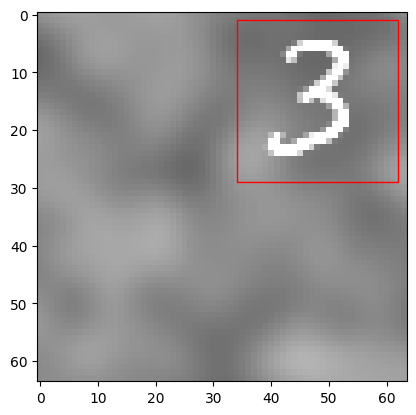

In [7]:
i = random.randint(0, train_x_new.shape[0])
show_prediction(train_x_new[i], train_y_new[i])

### Визуализация Ground-Truth образца

# Классиифкация и Локализация

### Создание модели для классификации и локализации
Теперь наш датасет готов, так что давайти создадим и обучим на нём модель для классификации и локализации. Она будет очень похожа на обычную CNN для классификации, но здесь мы сделаем так, что выход из последнего слоя будет содержать не просто распределение веротяностей по классам, а еще и координаты прямоугольника для каждого класса. Итого 10*(1+4) чисел на выходе. Для удобства отделим в выходном тензоре размерностии, соответствующие классам и пятёрке, отвечающей за один класс (с помощью reshape). Таким образом, выходной тензор будет иметь размерность (количество образцов, количество классов, 5)

**[ЗАДАНИЕ 1]** Вопрос: Почему для такой архитектуры в последнем слое (`fc2`) мы не можем сразу указать функцию активации `softmax`, и нам приходится здсь использовать `None`, а softmax навешивать уже потом (в лоссе)?

In [26]:
class Model(tf.keras.Model):

    def __init__(self):
        super(Model, self).__init__()

        self.conv1 = tf.keras.layers.Conv2D(32, (5, 5), activation=tf.nn.relu, padding='same')
        self.conv2 = tf.keras.layers.Conv2D(64, (5, 5), activation=tf.nn.relu, padding='same')
        self.conv3 = tf.keras.layers.Conv2D(128, (5, 5), activation=tf.nn.relu, padding='same')
        self.conv4 = tf.keras.layers.Conv2D(128, (5, 5), activation=tf.nn.relu, padding='same')
        self.fc1 = tf.keras.layers.Dense(256, activation=tf.nn.relu)
        self.fc2 = tf.keras.layers.Dense(5*10, activation=None)
        self.max_pool = tf.keras.layers.MaxPooling2D((2, 2), (2, 2), padding='same')

    def call(self, inp):

        out = self.conv1(inp)
        out = self.max_pool(out)
        out = self.conv2(out)
        out = self.max_pool(out)
        out = self.conv3(out)
        out = self.max_pool(out)
        out = self.conv4(out)
        out = self.max_pool(out)
        out = tf.layers.flatten(out)
        out = self.fc1(out)
        out = self.fc2(out)
        out = tf.reshape(out, (-1, out.shape[1]//5, 5))

        return out

model = Model()

### Функция потерь (Loss)
Зададим функцию потерь. В этом премере она будет не совсем стандартной. Так как теперь наша модель выдаёт и информацию про метку класса и информацию про ограничивающие прямоугольники, нам надо будет учесть и то и то. Для этого нам понадобятся два лосса: один для классификации (`loss_cls`), дургой для регрессии (`loss_box`).

Каждый из этих лоссов будет применяться к определённой части тензоров, соответствующих выходу сети и Ground-Truth. Классификационный лосс будем применять для элементов `[:,:,0]`, а локализационный для элементов `[:,:,1:]`, ибо так мы пострили наш Ground-Truth. Для классификации будем применять `softmax_cross_entropy` (в этом лоссе нужен дополнительный софтмакс, так как мы не использовали софтмакс в самой модели). Для регрессии -- `mean_squared_error` (MSE).

Далее нам нужно будет получить единый лосс, как взвешеную сумму `loss_cls` и `loss_box`. За взвешивание будет отвечать параметр `LAMBDA`, величина которого будет отвечать за то, чему больше должна уделять внимание нейроннная сеть -- классификации или локализации. Это гиперпараметр.

**[ЗАДАНИЕ 2]** Вопрос: Каковы размеры тензора `logits_box`, при условии, что batch_size = 64?

In [27]:
def loss_cls(labels, logits):
    logits_cls = logits[:,:,0]
    labels_cls = labels[:,:,0]
    return tf.losses.softmax_cross_entropy(labels_cls, logits_cls)

def loss_box(labels, logits):
    logits_box = logits[:,:,1:]
    labels_box = labels[:,:,1:]
    return tf.losses.mean_squared_error(labels_box, logits_box)

LAMBDA = 1.0
def loss_composit(labels, logits):
    return loss_cls(labels, logits) + LAMBDA * loss_box(labels, logits)

### Обучение

**[ЗАДАНИЕ 3]** Реализуйте пайплайн обучения описанной выше модели `model`, как это делалось для других задач обучения в tensorFlow. Используйте созданные выше `train_x_new` и `train_y_new` в качестве обучающего датасета. Во время обучения минимизируйте композитный лосс `loss_composit`. Постройте график зависимости лосса от эпохи.

In [111]:
class Model(tf.keras.Model):
    def __init__(self, lambda_reg=0.5):
        super(Model, self).__init__()
        #сверточные слои для извлечения признаков

        self.conv1 = tf.keras.layers.Conv2D(32, (5, 5), activation=tf.nn.relu, padding='same')
        self.conv2 = tf.keras.layers.Conv2D(64, (5, 5), activation=tf.nn.relu, padding='same')
        self.conv3 = tf.keras.layers.Conv2D(128, (5, 5), activation=tf.nn.relu, padding='same')
        self.conv4 = tf.keras.layers.Conv2D(128, (5, 5), activation=tf.nn.relu, padding='same')
        self.fc1 = tf.keras.layers.Dense(256, activation='relu')
        self.fc2 = tf.keras.layers.Dense(5*10, activation=None)
        self.max_pool = tf.keras.layers.MaxPooling2D((2,2), (2,2), padding='same')

        #параметр для баланса потерь классификации и локализации
        self.lambda_reg = lambda_reg

    def call(self, inp):

        #извлечение признаков
        out = self.conv1(inp)
        out = self.max_pool(out)
        out = self.conv2(out)
        out = self.max_pool(out)
        out = self.conv3(out)
        out = self.max_pool(out)
        out = self.conv4(out)
        out = self.max_pool(out)
        out = tf.keras.layers.Flatten()(out)
        out = self.fc1(out)
        out = self.fc2(out)
        out = tf.reshape(out, (-1, out.shape[1]//5, 5))


        return out

    def loss_cls(self, labels, logits):

        logits_cls = logits[:, :, 0]
        labels_cls = labels[:, :, 0]  # [batch, classes] где 0 или 1

        # Binary crossentropy для multi-label (каждый класс независимо)
        return tf.keras.losses.binary_crossentropy(
            labels_cls, logits_cls, from_logits=True
        )

    def loss_box(self, labels, logits):

        logits_box = logits[:, :, 1:]
        labels_box = labels[:, :, 1:]

        # Маска: 1 где есть объект (первый элемент = 1)
        has_object = tf.expand_dims(labels[:, :, 0], axis=-1)

        squared_error = tf.square(labels_box - logits_box) * has_object
        valid_count = tf.reduce_sum(has_object) + 1e-8
        return tf.reduce_sum(squared_error) / valid_count


    def loss_composit(self, labels, logits):
        return self.loss_cls(labels, logits) + self.lambda_reg * self.loss_box(labels, logits)



In [112]:
#строим модель передав тестовый тензор
model = Model(lambda_reg=0.5)
#test_input = tf.random.normal([1, 64, 64, 1])
#_ = model(test_input)

In [113]:
#компилируем модель
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=model.loss_composit,  # Используем композитную функцию потерь
    metrics=['accuracy']
)

In [ ]:
#запускать, как альтернативу
#кастомная компиляция
# Или создаем кастомные метрики
def localization_accuracy(y_true, y_pred):
    # Для простоты: считаем класс угаданным, если вероятность > 0.5
    true_classes = y_true[:, :, 0]
    pred_classes = tf.sigmoid(y_pred[:, :, 0])  # Преобразуем логиты в вероятности
    return tf.keras.metrics.binary_accuracy(true_classes, pred_classes)

def box_iou_metric(y_true, y_pred):
    # Метрика IoU (Intersection over Union) для боксов
    true_boxes = y_true[:, :, 1:]  # [batch, classes, 4]
    pred_boxes = y_pred[:, :, 1:]  # [batch, classes, 4]

    # Вычисляем IoU для каждого бокса
    # Здесь упрощенная версия - нужно реализовать полный расчет IoU
    box_diff = tf.abs(true_boxes - pred_boxes)
    box_accuracy = 1.0 - tf.reduce_mean(box_diff, axis=[1, 2])
    return box_accuracy

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=model.loss_composit,
    metrics=[localization_accuracy, box_iou_metric]
)

In [116]:
import os
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

#создаём папку для сохранения весов в вашей системе
checkpoint_dir = r'C:\Users\user0907\dowloadPython_clean\checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"Папка для чекпоинтов: {checkpoint_dir}")


#настраиваем колбеки
checkpoint_full = ModelCheckpoint(
    os.path.join(checkpoint_dir, 'full_model.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    save_weights_only=False,  #сохраняем всю модель
    verbose=1
)

#чекпоинт для всей модели (большой файл, но можно загрузить без кода)
checkpoint = ModelCheckpoint(
    os.path.join(checkpoint_dir, 'best_model_weights.weights.h5'),
    save_best_only=True,
    mode='max',
    save_weights_only=True,  #сохраняем только веса
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-8,
    verbose=1
)

#колбек для логов в TensorBoard
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=os.path.join(checkpoint_dir, 'logs'),
    histogram_freq=1
)

callbacks_list = [checkpoint, checkpoint_full, early_stop, reduce_lr, tensorboard_callback]

Папка для чекпоинтов: C:\Users\user0907\dowloadPython_clean\checkpoints


In [154]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import tensorflow as tf

def visualize_predictions(images, true_labels, predictions, num_samples=3):
    """
    Визуализация предсказаний для задачи классификации и локализации.

    Args:
        images: Тензор изображений [batch, 64, 64, 1] или [batch, 64, 64]
        true_labels: Истинные метки [batch, 10, 5]
        predictions: Предсказания модели [batch, 10, 5]
        num_samples: Количество примеров для отображения
    """
    # Если images имеет 3 измерения, добавляем ось batch
    if len(images.shape) == 3:
        images = images[np.newaxis, ...]

    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 5*num_samples))

    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(min(num_samples, len(images))):
        # 1. Исходное изображение с ИСТИННЫМ bounding box
        ax1 = axes[i, 0] if num_samples > 1 else axes[0]

        # Отображаем изображение (убираем последнюю ось если нужно)
        if images[i].shape[-1] == 1:
            ax1.imshow(images[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
        else:
            ax1.imshow(images[i], cmap='gray', vmin=0, vmax=1)

        ax1.set_title(f'True - Sample {i+1}')
        ax1.axis('off')

        # Находим истинный класс (для softmax - argmax one-hot вектора)
        true_class_idx = np.argmax(true_labels[i, :, 0])  # One-hot -> индекс класса

        # Проверяем, есть ли объект (должен быть, если метки корректны)
        if true_labels[i, true_class_idx, 0] > 0.5:
            # Извлекаем координаты истинного bounding box
            x, y, w, h = true_labels[i, true_class_idx, 1:]

            # Преобразуем нормализованные координаты в пиксели
            img_h, img_w = images[i].shape[0], images[i].shape[1]
            x_pix = (x - w/2) * img_w
            y_pix = (y - h/2) * img_h
            w_pix = w * img_w
            h_pix = h * img_h

            # Рисуем истинный bounding box (ЗЕЛЕНЫЙ)
            rect_true = patches.Rectangle(
                (x_pix, y_pix), w_pix, h_pix,
                linewidth=3, edgecolor='green', facecolor='none',
                label=f'True: {true_class_idx}'
            )
            ax1.add_patch(rect_true)
            ax1.legend(loc='upper right')

        # 2. Исходное изображение с ПРЕДСКАЗАННЫМ bounding box
        ax2 = axes[i, 1] if num_samples > 1 else axes[1]

        if images[i].shape[-1] == 1:
            ax2.imshow(images[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
        else:
            ax2.imshow(images[i], cmap='gray', vmin=0, vmax=1)

        ax2.set_title(f'Predicted - Sample {i+1}')
        ax2.axis('off')

        # Для предсказаний: softmax по логитам (у вас categorical crossentropy)
        pred_logits = predictions[i, :, 0]
        pred_probs = tf.nn.softmax(pred_logits).numpy()  # SOFTMAX, не sigmoid!
        pred_class_idx = np.argmax(pred_probs)
        pred_prob = pred_probs[pred_class_idx]

        if pred_prob > 0.5:  # Если модель уверена
            # Извлекаем координаты предсказанного bounding box
            x_pred, y_pred, w_pred, h_pred = predictions[i, pred_class_idx, 1:]

            # Преобразуем в пиксели
            x_pix_pred = (x_pred - w_pred/2) * img_w
            y_pix_pred = (y_pred - h_pred/2) * img_h
            w_pix_pred = w_pred * img_w
            h_pix_pred = h_pred * img_h

            # Рисуем предсказанный bounding box (КРАСНЫЙ)
            rect_pred = patches.Rectangle(
                (x_pix_pred, y_pix_pred), w_pix_pred, h_pix_pred,
                linewidth=3, edgecolor='red', facecolor='none',
                label=f'Pred: {pred_class_idx} ({pred_prob:.2f})'
            )
            ax2.add_patch(rect_pred)
            ax2.legend(loc='upper right')

        # 3. Выводим информацию в консоль
        print(f"\n{'='*50}")
        print(f"Sample {i+1}:")
        print(f"  True class: {true_class_idx}")
        print(f"  Predicted class: {pred_class_idx} (probability: {pred_prob:.4f})")

        # Если класс угадан, сравниваем bounding boxes
        if true_class_idx == pred_class_idx and pred_prob > 0.5:
            # Вычисляем IoU (Intersection over Union)
            def calculate_iou(box1, box2):
                """Вычисляет IoU для двух нормализованных bounding boxes"""
                x1, y1, w1, h1 = box1
                x2, y2, w2, h2 = box2

                # Координаты углов
                x1_min, x1_max = x1 - w1/2, x1 + w1/2
                y1_min, y1_max = y1 - h1/2, y1 + h1/2
                x2_min, x2_max = x2 - w2/2, x2 + w2/2
                y2_min, y2_max = y2 - h2/2, y2 + h2/2

                # Пересечение
                inter_xmin = max(x1_min, x2_min)
                inter_ymin = max(y1_min, y2_min)
                inter_xmax = min(x1_max, x2_max)
                inter_ymax = min(y1_max, y2_max)

                inter_width = max(0, inter_xmax - inter_xmin)
                inter_height = max(0, inter_ymax - inter_ymin)
                inter_area = inter_width * inter_height

                # Площади боксов
                area1 = w1 * h1
                area2 = w2 * h2

                # Объединение
                union_area = area1 + area2 - inter_area

                return inter_area / union_area if union_area > 0 else 0

            iou = calculate_iou([x, y, w, h], [x_pred, y_pred, w_pred, h_pred])
            print(f"  IoU (Intersection over Union): {iou:.4f}")

            # Разница в координатах
            coord_diff = np.abs(np.array([x, y, w, h]) - np.array([x_pred, y_pred, w_pred, h_pred]))
            print(f"  Coordinate differences: {coord_diff}")
            print(f"  Average diff: {np.mean(coord_diff):.4f}")
        else:
            print(f"  Class mismatch or low confidence!")

    plt.tight_layout()
    plt.show()

In [118]:
# Добавьте перед обучением
print("Проверка формата данных:")
print(f"train_x_new shape: {train_x_new.shape}")  # Должно быть (N, 64, 64, 1)
print(f"train_y_new shape: {train_y_new.shape}")  # Должно быть (N, 10, 5)

# Проверьте значения в метках
print("\nПример метки (первые 2 класса):")
for i in range(2):
    print(f"Класс {i}: {train_y_new[0, i]}")

# Проверьте, есть ли ненулевые значения в первом элементе (классификация)
class_presence = tf.reduce_sum(train_y_new[:, :, 0])
print(f"\nСумма по компоненте классификации: {class_presence.numpy()}")
# Должно быть > 0, иначе все метки нулевые!

Проверка формата данных:
train_x_new shape: (5000, 64, 64, 1)
train_y_new shape: (5000, 10, 5)

Пример метки (первые 2 класса):
Класс 0: [ 0. -1. -1. -1. -1.]
Класс 1: [1.       0.625    0.671875 0.4375   0.4375  ]

Сумма по компоненте классификации: 7061.0


In [119]:
#обучаем модель
history = model.fit(
    train_x_new,
    train_y_new,
    validation_data=(test_x_new, test_y_new),
    epochs=10,
    batch_size=32,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0037 - loss: 0.6181
Epoch 1: val_loss improved from -inf to 0.43335, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/best_model_weights.weights.h5

Epoch 1: val_accuracy improved from -inf to 0.00000, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/full_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.0037 - loss: 0.6173 - val_accuracy: 0.0000e+00 - val_loss: 0.4334 - learning_rate: 0.0010
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0000e+00 - loss: 0.4337
Epoch 2: val_loss did not improve from 0.43335

Epoch 2: val_accuracy did not improve from 0.00000
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.0000e+00 - loss: 0.4337 - val_accuracy: 0.0000e+00 - val_loss: 0.4198 - learning_rate: 0.0010
Epoch 3/10
155/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.4293e-05 - loss: 0.4172
Epoch 3: val_loss did not improve from 0.43335

Epoch 3: val_accuracy did not improve from 0.00000
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 1.8201e-05 - loss: 0.4171 - val_accuracy: 0.0000e+00 - val_loss: 0.4170 - learning_rate: 0.0010
Epoch 4/10
152/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0061 - loss: 0.3853
Epoch 4: val_loss did not improve from 0.43335

Epoch 4: val_accuracy improved from 0.

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.0063 - loss: 0.3848 - val_accuracy: 0.0196 - val_loss: 0.3436 - learning_rate: 0.0010
Epoch 5/10
152/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0172 - loss: 0.3152
Epoch 5: val_loss did not improve from 0.43335

Epoch 5: val_accuracy improved from 0.01960 to 0.04200, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/full_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.0176 - loss: 0.3143 - val_accuracy: 0.0420 - val_loss: 0.2626 - learning_rate: 0.0010
Epoch 6/10
155/157 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0537 - loss: 0.2346
Epoch 6: val_loss did not improve from 0.43335

Epoch 6: val_accuracy improved from 0.04200 to 0.06000, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/full_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.0537 - loss: 0.2344 - val_accuracy: 0.0600 - val_loss: 0.2100 - learning_rate: 0.0010
Epoch 7/10
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0743 - loss: 0.1828
Epoch 7: val_loss did not improve from 0.43335

Epoch 7: val_accuracy improved from 0.06000 to 0.08760, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/full_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.0744 - loss: 0.1826 - val_accuracy: 0.0876 - val_loss: 0.1555 - learning_rate: 0.0010
Epoch 8/10
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1031 - loss: 0.1237
Epoch 8: val_loss did not improve from 0.43335

Epoch 8: val_accuracy improved from 0.08760 to 0.11290, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/full_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1031 - loss: 0.1235 - val_accuracy: 0.1129 - val_loss: 0.1114 - learning_rate: 0.0010
Epoch 9/10
152/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1236 - loss: 0.0821
Epoch 9: val_loss did not improve from 0.43335

Epoch 9: val_accuracy improved from 0.11290 to 0.11450, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/full_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1235 - loss: 0.0818 - val_accuracy: 0.1145 - val_loss: 0.0888 - learning_rate: 0.0010
Epoch 10/10
152/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1284 - loss: 0.0611
Epoch 10: val_loss did not improve from 0.43335

Epoch 10: val_accuracy improved from 0.11450 to 0.11570, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/full_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.1284 - loss: 0.0609 - val_accuracy: 0.1157 - val_loss: 0.0871 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.


In [120]:
model = Model(lambda_reg=0.5)

In [121]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=model.loss_composit,  # Используем композитную функцию потерь
    metrics=['accuracy']
)

In [122]:
import os
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

#создаём папку для сохранения весов в вашей системе
checkpoint_dir = r'C:\Users\user0907\dowloadPython_clean\checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"Папка для чекпоинтов: {checkpoint_dir}")


#настраиваем колбеки
checkpoint_full = ModelCheckpoint(
    os.path.join(checkpoint_dir, 'full_model.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    save_weights_only=False,  #сохраняем всю модель
    verbose=1
)

#чекпоинт для всей модели (большой файл, но можно загрузить без кода)
checkpoint = ModelCheckpoint(
    os.path.join(checkpoint_dir, 'best_model_weights.weights.h5'),
    save_best_only=True,
    mode='max',
    save_weights_only=True,  #сохраняем только веса
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-8,
    verbose=1
)

#колбек для логов в TensorBoard
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=os.path.join(checkpoint_dir, 'logs'),
    histogram_freq=1
)

callbacks_list = [checkpoint, checkpoint_full, early_stop, reduce_lr, tensorboard_callback]

Папка для чекпоинтов: C:\Users\user0907\dowloadPython_clean\checkpoints


In [123]:
history_lambda1 = model.fit(
    train_x_new,  # Все 5000 примеров
    train_y_new,
    validation_data=(test_x_new, test_y_new),
    epochs=100,  # 100 эпох
    batch_size=32,
    callbacks=callbacks_list,
    verbose=1
)


Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0062 - loss: 0.5879
Epoch 1: val_loss improved from -inf to 0.43868, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/best_model_weights.weights.h5

Epoch 1: val_accuracy improved from -inf to 0.00000, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/full_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.0061 - loss: 0.5873 - val_accuracy: 0.0000e+00 - val_loss: 0.4387 - learning_rate: 0.0010
Epoch 2/100
154/157 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0000e+00 - loss: 0.4401
Epoch 2: val_loss did not improve from 0.43868

Epoch 2: val_accuracy did not improve from 0.00000
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.0000e+00 - loss: 0.4399 - val_accuracy: 0.0000e+00 - val_loss: 0.4203 - learning_rate: 0.0010
Epoch 3/100
153/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.9065e-04 - loss: 0.4188
Epoch 3: val_loss did not improve from 0.43868

Epoch 3: val_accuracy improved from 0.00000 to 0.01180, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/full_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 2.3561e-04 - loss: 0.4184 - val_accuracy: 0.0118 - val_loss: 0.3732 - learning_rate: 0.0010
Epoch 4/100
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0109 - loss: 0.3571
Epoch 4: val_loss did not improve from 0.43868

Epoch 4: val_accuracy improved from 0.01180 to 0.02480, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/full_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.0110 - loss: 0.3569 - val_accuracy: 0.0248 - val_loss: 0.3060 - learning_rate: 0.0010
Epoch 5/100
153/157 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0309 - loss: 0.2804
Epoch 5: val_loss did not improve from 0.43868

Epoch 5: val_accuracy improved from 0.02480 to 0.05840, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/full_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.0311 - loss: 0.2799 - val_accuracy: 0.0584 - val_loss: 0.2497 - learning_rate: 0.0010
Epoch 6/100
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0610 - loss: 0.2113
Epoch 6: val_loss did not improve from 0.43868

Epoch 6: val_accuracy improved from 0.05840 to 0.07520, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/full_model.h5


...

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1283 - loss: 0.0577 - val_accuracy: 0.1262 - val_loss: 0.0713 - learning_rate: 0.0010
Epoch 10/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1343 - loss: 0.0408
Epoch 10: val_loss did not improve from 0.43868

Epoch 10: val_accuracy did not improve from 0.12620
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1343 - loss: 0.0408 - val_accuracy: 0.1259 - val_loss: 0.0659 - learning_rate: 0.0010
Epoch 11/100
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1361 - loss: 0.0289
Epoch 11: val_loss did not improve from 0.43868

Epoch 11: val_accuracy improved from 0.12620 to 0.12800, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/full_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1361 - loss: 0.0289 - val_accuracy: 0.1280 - val_loss: 0.0574 - learning_rate: 0.0010
Epoch 12/100
153/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1385 - loss: 0.0221
Epoch 12: val_loss did not improve from 0.43868

Epoch 12: val_accuracy improved from 0.12800 to 0.13200, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/full_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1385 - loss: 0.0221 - val_accuracy: 0.1320 - val_loss: 0.0640 - learning_rate: 0.0010
Epoch 13/100
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1396 - loss: 0.0155
Epoch 13: val_loss did not improve from 0.43868

Epoch 13: val_accuracy did not improve from 0.13200
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.1397 - loss: 0.0155 - val_accuracy: 0.1294 - val_loss: 0.0495 - learning_rate: 0.0010
Epoch 14/100
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1421 - loss: 0.0119
Epoch 14: val_loss did not improve from 0.43868

Epoch 14: val_accuracy did not improve from 0.13200
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.1421 - loss: 0.0119 - val_accuracy: 0.1310 - val_loss: 0.0440 - learning_rate: 0.0010
Epoch 15/100
153/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1426 - loss: 0.0097
Epoch 15: val_loss did not improve from 0.43868

Epoch 15: val_accuracy did not improve from 0.13200
157/

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1413 - loss: 0.0061 - val_accuracy: 0.1322 - val_loss: 0.0424 - learning_rate: 0.0010
Epoch 18/100
152/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1424 - loss: 0.0058
Epoch 18: val_loss did not improve from 0.43868

Epoch 18: val_accuracy improved from 0.13220 to 0.13260, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/full_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1424 - loss: 0.0058 - val_accuracy: 0.1326 - val_loss: 0.0387 - learning_rate: 0.0010
Epoch 19/100
153/157 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1402 - loss: 0.0052
Epoch 19: val_loss did not improve from 0.43868

Epoch 19: val_accuracy did not improve from 0.13260
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.1402 - loss: 0.0052 - val_accuracy: 0.1326 - val_loss: 0.0383 - learning_rate: 0.0010
Epoch 20/100
152/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1402 - loss: 0.0047
Epoch 20: val_loss did not improve from 0.43868

Epoch 20: val_accuracy did not improve from 0.13260
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.1403 - loss: 0.0047 - val_accuracy: 0.1310 - val_loss: 0.0387 - learning_rate: 0.0010
Epoch 21/100
153/157 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1403 - loss: 0.0043
Epoch 21: val_loss did not improve from 0.43868

Epoch 21: val_accuracy did not improve from 0.13260
157/

In [126]:
print("=== ТЕСТ ПРЕДСКАЗАНИЙ ===")
# Берем несколько тестовых примеров
test_samples = 5
test_pred = model.predict(test_x_new[:test_samples])

for i in range(test_samples):
    print(f"\nПример {i}:")

    # Истинные классы
    true_classes = []
    for cls in range(10):
        if test_y_new[i, cls, 0] == 1.0:
            true_classes.append(cls)

    # Предсказанные классы (вероятность > 0.5)
    pred_classes = []
    pred_probs = tf.sigmoid(test_pred[i, :, 0]).numpy()
    for cls in range(10):
        if pred_probs[cls] > 0.5:
            pred_classes.append(f"{cls}({pred_probs[cls]:.2f})")

    print(f"  Истинные классы: {true_classes}")
    print(f"  Предсказанные классы: {pred_classes}")

    # Сравнение bounding boxes
    for cls in true_classes:
        if cls in [int(p.split('(')[0]) for p in pred_classes]:
            true_box = test_y_new[i, cls, 1:]
            pred_box = test_pred[i, cls, 1:]
            print(f"  Класс {cls}: True {true_box}, Pred {pred_box}")

=== ТЕСТ ПРЕДСКАЗАНИЙ ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Пример 0:
  Истинные классы: [1, 6]
  Предсказанные классы: ['6(0.99)']
  Класс 6: True [0.625    0.703125 0.4375   0.4375  ], Pred [0.6317754  0.64663965 0.46386665 0.44795266]

Пример 1:
  Истинные классы: [8]
  Предсказанные классы: ['8(0.98)']
  Класс 8: True [0.234375 0.328125 0.4375   0.4375  ], Pred [0.2337965  0.30717096 0.4440403  0.31061015]

Пример 2:
  Истинные классы: [5]
  Предсказанные классы: ['5(1.00)']
  Класс 5: True [0.34375  0.609375 0.4375   0.4375  ], Pred [0.17871526 0.58264357 0.45957637 0.37368786]

Пример 3:
  Истинные классы: [5]
  Предсказанные классы: ['5(1.00)']
  Класс 5: True [0.59375 0.40625 0.4375  0.4375 ], Pred [0.42098942 0.3450688  0.40389258 0.43710428]

Пример 4:
  Истинные классы: [1]
  Предсказанные классы: ['1(0.72)']
  Класс 1: True [0.65625  0.296875 0.4375   0.4375  ], Pred [0.7562489  0.37567154 0.3561565  0.46561486]


In [133]:
# Используем ВЕСЬ MNIST (60000 тренировочных)
train_x_full, train_y_full = convert_to_loc_ds(
    train_x, train_y, bg_source, new_size, max_digits=3
)
test_x_full, test_y_full = convert_to_loc_ds(
    test_x, test_y, bg_source, new_size, max_digits=3
)

print(f"Полный train датасет: {train_x_full.shape}")  # (60000, 64, 64, 1)
print(f"Полный test датасет: {test_x_full.shape}")    # (10000, 64, 64, 1)

# Сохраняем 20% для валидации
val_split = 0.2
split_idx = int(len(train_x_full) * (1 - val_split))
train_x_final = train_x_full[:split_idx]
train_y_final = train_y_full[:split_idx]
val_x_final = train_x_full[split_idx:]
val_y_final = train_y_full[split_idx:]

Полный train датасет: (60000, 64, 64, 1)
Полный test датасет: (10000, 64, 64, 1)


In [129]:
class FixedModel(tf.keras.Model):
    def __init__(self, lambda_reg=0.5):
        super(FixedModel, self).__init__()
        #сверточные слои для извлечения признаков

        self.conv1 = tf.keras.layers.Conv2D(32, (5, 5), activation=tf.nn.relu, padding='same')
        self.conv2 = tf.keras.layers.Conv2D(64, (5, 5), activation=tf.nn.relu, padding='same')
        self.conv3 = tf.keras.layers.Conv2D(128, (5, 5), activation=tf.nn.relu, padding='same')
        self.conv4 = tf.keras.layers.Conv2D(128, (5, 5), activation=tf.nn.relu, padding='same')
        self.fc1 = tf.keras.layers.Dense(256, activation='relu')
        self.fc2 = tf.keras.layers.Dense(5*10, activation=None)
        self.max_pool = tf.keras.layers.MaxPooling2D((2,2), (2,2), padding='same')

        #параметр для баланса потерь классификации и локализации
        self.lambda_reg = lambda_reg

    def call(self, inp):

        #извлечение признаков
        out = self.conv1(inp)
        out = self.max_pool(out)
        out = self.conv2(out)
        out = self.max_pool(out)
        out = self.conv3(out)
        out = self.max_pool(out)
        out = self.conv4(out)
        out = self.max_pool(out)
        out = tf.keras.layers.Flatten()(out)
        out = self.fc1(out)
        out = self.fc2(out)
        out = tf.reshape(out, (-1, out.shape[1]//5, 5))


        return out

    def loss_cls(self, labels, logits):

        logits_cls = logits[:, :, 0]
        labels_cls = labels[:, :, 0]  # [batch, classes] где 0 или 1
        loss = tf.keras.losses.binary_crossentropy(labels_cls, logits_cls, from_logits=True)
        # Binary crossentropy для multi-label (каждый класс независимо)
        return tf.reduce_mean(loss)

    def loss_box(self, labels, logits):

        logits_box = logits[:, :, 1:]
        labels_box = labels[:, :, 1:]

        # Маска: 1 где есть объект (первый элемент = 1)
        has_object = tf.expand_dims(labels[:, :, 0], axis=-1)

        squared_error = tf.square(labels_box - logits_box) * has_object
        valid_count = tf.reduce_sum(has_object) + 1e-8
        return tf.reduce_sum(squared_error) / valid_count * 100.0 # Увеличиваем масштаб loss в 100 раз


    def loss_composit(self, labels, logits):
        cls_loss = self.loss_cls(labels, logits)
        box_loss = self.loss_box(labels, logits)
        total_loss = cls_loss + self.lambda_reg * box_loss
        return total_loss



In [130]:
# Создаем исправленную модель
fixed_model = FixedModel(lambda_reg=1.0)

In [132]:
# Компилируем исправленную модель
fixed_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=fixed_model.loss_composit,
    metrics=['accuracy']
)


In [131]:
import os
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

#создаём папку для сохранения весов в вашей системе
checkpoint_dir = r'C:\Users\user0907\dowloadPython_clean\checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"Папка для чекпоинтов: {checkpoint_dir}")


#настраиваем колбеки
checkpoint_full = ModelCheckpoint(
    os.path.join(checkpoint_dir, 'full_model.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    save_weights_only=False,  #сохраняем всю модель
    verbose=1
)

#чекпоинт для всей модели (большой файл, но можно загрузить без кода)
checkpoint = ModelCheckpoint(
    os.path.join(checkpoint_dir, 'best_model_weights.weights.h5'),
    save_best_only=True,
    mode='max',
    save_weights_only=True,  #сохраняем только веса
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-8,
    verbose=1
)

#колбек для логов в TensorBoard
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=os.path.join(checkpoint_dir, 'logs'),
    histogram_freq=1
)

callbacks_list = [checkpoint, checkpoint_full, early_stop, reduce_lr, tensorboard_callback]

Папка для чекпоинтов: C:\Users\user0907\dowloadPython_clean\checkpoints


In [134]:
history_fixed = fixed_model.fit(
    train_x_final,  # Весь датасет (48000 примеров)
    train_y_final,
    validation_data=(val_x_final, val_y_final),
    epochs=150,  # Больше эпох
    batch_size=64,  # Больше batch
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/150
748/750 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0024 - loss: 12.6801
Epoch 1: val_loss improved from -inf to 2.80456, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/best_model_weights.weights.h5

Epoch 1: val_accuracy improved from -inf to 0.00000, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/full_model.h5


750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.0024 - loss: 12.6546 - val_accuracy: 0.0000e+00 - val_loss: 2.8046 - learning_rate: 0.0010
Epoch 2/150
747/750 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0000e+00 - loss: 2.1699
Epoch 2: val_loss did not improve from 2.80456

Epoch 2: val_accuracy did not improve from 0.00000
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.0000e+00 - loss: 2.1680 - val_accuracy: 0.0000e+00 - val_loss: 1.4124 - learning_rate: 0.0010
Epoch 3/150
749/750 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0000e+00 - loss: 1.3159
Epoch 3: val_loss did not improve from 2.80456

Epoch 3: val_accuracy did not improve from 0.00000
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.0000e+00 - loss: 1.3158 - val_accuracy: 0.0000e+00 - val_loss: 1.1763 - learning_rate: 0.0010
Epoch 4/150
748/750 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 4.1648e-04 - loss: 1.0283
Epoch 4: val_loss did not improve from 2.80456

Epoch 4: val_accuracy improv

750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 4.2148e-04 - loss: 1.0283 - val_accuracy: 0.0059 - val_loss: 1.0130 - learning_rate: 0.0010
Epoch 5/150
749/750 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0095 - loss: 0.8899
Epoch 5: val_loss did not improve from 2.80456

Epoch 5: val_accuracy improved from 0.00592 to 0.01517, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/full_model.h5


750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.0095 - loss: 0.8898 - val_accuracy: 0.0152 - val_loss: 0.8965 - learning_rate: 0.0010
Epoch 6/150
748/750 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0312 - loss: 0.7458
Epoch 6: val_loss did not improve from 2.80456

Epoch 6: val_accuracy improved from 0.01517 to 0.05772, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/full_model.h5


750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.0312 - loss: 0.7458 - val_accuracy: 0.0577 - val_loss: 0.8354 - learning_rate: 0.0010
Epoch 7/150
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0710 - loss: 0.6355
Epoch 7: val_loss did not improve from 2.80456

Epoch 7: val_accuracy improved from 0.05772 to 0.09510, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/full_model.h5


...

750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.1377 - loss: 0.1145 - val_accuracy: 0.1371 - val_loss: 0.5092 - learning_rate: 0.0010
Epoch 24/150
748/750 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1379 - loss: 0.1147
Epoch 24: val_loss did not improve from 2.80456

Epoch 24: val_accuracy did not improve from 0.13712
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.1379 - loss: 0.1147 - val_accuracy: 0.1363 - val_loss: 0.4818 - learning_rate: 0.0010
Epoch 25/150
748/750 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1383 - loss: 0.1051
Epoch 25: val_loss did not improve from 2.80456

Epoch 25: val_accuracy did not improve from 0.13712
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.1383 - loss: 0.1051 - val_accuracy: 0.1365 - val_loss: 0.4834 - learning_rate: 0.0010
Epoch 26/150
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1386 - loss: 0.1000
Epoch 26: val_loss did not improve from 2.80456

Epoch 26: val_accuracy did not improve from 0.13712
7

750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.1388 - loss: 0.0937 - val_accuracy: 0.1373 - val_loss: 0.4589 - learning_rate: 0.0010
Epoch 30/150
749/750 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1388 - loss: 0.0858
Epoch 30: val_loss did not improve from 2.80456

Epoch 30: val_accuracy did not improve from 0.13728
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.1388 - loss: 0.0858 - val_accuracy: 0.1363 - val_loss: 0.4653 - learning_rate: 0.0010
Epoch 31/150
749/750 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1392 - loss: 0.0855
Epoch 31: val_loss did not improve from 2.80456

Epoch 31: val_accuracy did not improve from 0.13728
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.1392 - loss: 0.0855 - val_accuracy: 0.1364 - val_loss: 0.4538 - learning_rate: 0.0010
Epoch 32/150
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1393 - loss: 0.0798
Epoch 32: val_loss did not improve from 2.80456

Epoch 32: val_accuracy improved from 0.13728 to 0.137

750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.1393 - loss: 0.0799 - val_accuracy: 0.1374 - val_loss: 0.4615 - learning_rate: 0.0010
Epoch 33/150
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1392 - loss: 0.0780
Epoch 33: val_loss did not improve from 2.80456

Epoch 33: val_accuracy did not improve from 0.13739
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.1392 - loss: 0.0780 - val_accuracy: 0.1367 - val_loss: 0.4424 - learning_rate: 0.0010
Epoch 34/150
747/750 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1391 - loss: 0.0765
Epoch 34: val_loss did not improve from 2.80456

Epoch 34: val_accuracy did not improve from 0.13739
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.1391 - loss: 0.0765 - val_accuracy: 0.1372 - val_loss: 0.4421 - learning_rate: 0.0010
Epoch 35/150
749/750 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1392 - loss: 0.0789
Epoch 35: val_loss did not improve from 2.80456

Epoch 35: val_accuracy improved from 0.13739 to 0.137

750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.1392 - loss: 0.0789 - val_accuracy: 0.1376 - val_loss: 0.4415 - learning_rate: 0.0010
Epoch 36/150
749/750 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1388 - loss: 0.0732
Epoch 36: val_loss did not improve from 2.80456

Epoch 36: val_accuracy did not improve from 0.13760
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.1388 - loss: 0.0732 - val_accuracy: 0.1375 - val_loss: 0.4267 - learning_rate: 0.0010
Epoch 37/150
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1393 - loss: 0.0676
Epoch 37: val_loss did not improve from 2.80456

Epoch 37: val_accuracy did not improve from 0.13760
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.1393 - loss: 0.0676 - val_accuracy: 0.1374 - val_loss: 0.4345 - learning_rate: 0.0010
Epoch 38/150
749/750 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1396 - loss: 0.0693
Epoch 38: val_loss did not improve from 2.80456

Epoch 38: val_accuracy did not improve from 0.13760
7

KeyboardInterrupt: 

In [10]:
class Model(tf.keras.Model):
    def __init__(self, lambda_reg=0.5):
        super(Model, self).__init__()
        #сверточные слои для извлечения признаков

        self.conv1 = tf.keras.layers.Conv2D(32, (5, 5), activation=tf.nn.relu, padding='same')
        self.conv2 = tf.keras.layers.Conv2D(64, (5, 5), activation=tf.nn.relu, padding='same')
        self.conv3 = tf.keras.layers.Conv2D(128, (5, 5), activation=tf.nn.relu, padding='same')
        self.conv4 = tf.keras.layers.Conv2D(128, (5, 5), activation=tf.nn.relu, padding='same')
        self.fc1 = tf.keras.layers.Dense(256, activation='relu')
        self.fc2 = tf.keras.layers.Dense(5*10, activation=None)
        self.max_pool = tf.keras.layers.MaxPooling2D((2,2), (2,2), padding='same')

        #параметр для баланса потерь классификации и локализации
        self.lambda_reg = lambda_reg

    def call(self, inp):

        #извлечение признаков
        out = self.conv1(inp)
        out = self.max_pool(out)
        out = self.conv2(out)
        out = self.max_pool(out)
        out = self.conv3(out)
        out = self.max_pool(out)
        out = self.conv4(out)
        out = self.max_pool(out)
        out = tf.keras.layers.Flatten()(out)
        out = self.fc1(out)
        out = self.fc2(out)
        out = tf.reshape(out, (-1, out.shape[1]//5, 5))


        return out

    def loss_cls(self, labels, logits):

        logits_cls = logits[:, :, 0]
        labels_cls = labels[:, :, 0]  # [batch, classes] где 0 или 1
        labels_cls = tf.where(labels_cls > 0.5, 1.0, 0.0)

        loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
        return loss_fn(labels_cls, logits_cls)

    def loss_box(self, labels, logits):

        logits_box = logits[:, :, 1:]
        labels_box = labels[:, :, 1:]
        # Создаем маску: 1 где координаты != -1, 0 где == -1
        mask = tf.cast(tf.not_equal(labels_box, -1.0), tf.float32)

        # Вычисляем MSE только для валидных координат
        box_diff = tf.square(labels_box - logits_box) * mask
        valid_count = tf.reduce_sum(mask) + 1e-8

        return tf.reduce_sum(box_diff) / valid_count


    def loss_composit(self, labels, logits):
        cls_loss = self.loss_cls(labels, logits)
        box_loss = self.loss_box(labels, logits)
        total_loss = cls_loss + self.lambda_reg * box_loss


        return total_loss


In [187]:
print("=== ЭКСПРЕСС-ДИАГНОСТИКА ===")

# Проверка 1: Формат меток
print("1. Проверка формата меток:")
print(f"train_y_new shape: {train_y_new.shape}")
print(f"Пример метки (первые 3 класса для первого изображения):")
for i in range(3):
    print(f"  Класс {i}: {train_y_new[0, i]}")

# Проверка 2: One-hot ли метки?
print("\n2. Проверка one-hot формата:")
for i in range(3):
    class_sum = np.sum(train_y_new[i, :, 0])
    print(f"Изображение {i}: сумма по классам = {class_sum}")
    if class_sum != 1.0:
        print(f"    НЕ one-hot! Найденные классы: {np.where(train_y_new[i, :, 0] > 0)[0]}")

# Проверка 3: Координаты bounding boxes
print("\n3. Проверка координат bounding boxes:")
valid_coords = []
for i in range(3):
    for cls in range(10):
        if train_y_new[i, cls, 0] == 1.0:
            coords = train_y_new[i, cls, 1:]
            valid_coords.append(coords)
            print(f"  Изображение {i}, класс {cls}: {coords}")

if valid_coords:
    valid_coords = np.array(valid_coords)
    print(f"  Минимальные координаты: {np.min(valid_coords, axis=0)}")
    print(f"  Максимальные координаты: {np.max(valid_coords, axis=0)}")

=== ЭКСПРЕСС-ДИАГНОСТИКА ===
1. Проверка формата меток:
train_y_new shape: (60000, 10, 5)
Пример метки (первые 3 класса для первого изображения):
  Класс 0: [ 0. -1. -1. -1. -1.]
  Класс 1: [ 0. -1. -1. -1. -1.]
  Класс 2: [ 0. -1. -1. -1. -1.]

2. Проверка one-hot формата:
Изображение 0: сумма по классам = 1.0
Изображение 1: сумма по классам = 1.0
Изображение 2: сумма по классам = 1.0

3. Проверка координат bounding boxes:
  Изображение 0, класс 5: [0.296875 0.0625   0.4375   0.4375  ]
  Изображение 1, класс 0: [0.359375 0.5625   0.4375   0.4375  ]
  Изображение 2, класс 4: [0.359375 0.390625 0.4375   0.4375  ]
  Минимальные координаты: [0.296875 0.0625   0.4375   0.4375  ]
  Максимальные координаты: [0.359375 0.5625   0.4375   0.4375  ]


In [188]:
print("\n=== ЧТО ПРЕДСКАЗЫВАЕТ МОДЕЛЬ? ===")

# Берем 5 примеров
test_samples = 5
test_pred = model.predict(test_x_new[:test_samples])

for i in range(test_samples):
    print(f"\nПример {i}:")

    # Истинные метки
    true_classes = np.where(test_y_new[i, :, 0] == 1.0)[0]
    print(f"  Истинные классы: {true_classes}")

    # Предсказания модели
    pred_logits = test_pred[i, :, 0]
    pred_probs = tf.nn.softmax(pred_logits).numpy()

    print(f"  Предсказанные вероятности (первые 5 классов):")
    for cls in range(min(5, 10)):
        print(f"    Класс {cls}: {pred_probs[cls]:.4f}")

    pred_class = np.argmax(pred_probs)
    print(f"  Предсказанный класс: {pred_class} (вероятность: {pred_probs[pred_class]:.4f})")

    # Bounding boxes
    if pred_probs[pred_class] > 0.5:
        pred_box = test_pred[i, pred_class, 1:]
        print(f"  Предсказанный bounding box: {pred_box}")
    else:
        print(f"    Низкая уверенность (< 0.5)")

    # Сравнение с истинным bounding box
    if len(true_classes) > 0:
        true_box = test_y_new[i, true_classes[0], 1:]
        print(f"  Истинный bounding box: {true_box}")


=== ЧТО ПРЕДСКАЗЫВАЕТ МОДЕЛЬ? ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step

Пример 0:
  Истинные классы: [7]
  Предсказанные вероятности (первые 5 классов):
    Класс 0: 0.1004
    Класс 1: 0.0997
    Класс 2: 0.0934
    Класс 3: 0.1022
    Класс 4: 0.0999
  Предсказанный класс: 6 (вероятность: 0.1048)
    Низкая уверенность (< 0.5)
  Истинный bounding box: [0.515625 0.015625 0.4375   0.4375  ]

Пример 1:
  Истинные классы: [2]
  Предсказанные вероятности (первые 5 классов):
    Класс 0: 0.1010
    Класс 1: 0.1012
    Класс 2: 0.0920
    Класс 3: 0.1013
    Класс 4: 0.1002
  Предсказанный класс: 6 (вероятность: 0.1043)
    Низкая уверенность (< 0.5)
  Истинный bounding box: [0.140625 0.5      0.4375   0.4375  ]

Пример 2:
  Истинные классы: [1]
  Предсказанные вероятности (первые 5 классов):
    Класс 0: 0.1010
    Класс 1: 0.1004
    Класс 2: 0.0927
    Класс 3: 0.1018
    Класс 4: 0.1004
  Предсказанный класс: 6 (вероятность: 0.1049)
    Низкая уверенность (< 0.5)
  Истинный bounding 

In [11]:
model = Model(lambda_reg=1.0)

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=model.loss_composit,  # Используем композитную функцию потерь
    metrics=['accuracy']
)

In [13]:
import os
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

#создаём папку для сохранения весов в вашей системе
checkpoint_dir = r'C:\Users\user0907\dowloadPython_clean\checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"Папка для чекпоинтов: {checkpoint_dir}")


#настраиваем колбеки
checkpoint_full = ModelCheckpoint(
    os.path.join(checkpoint_dir, 'full_model.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    save_weights_only=False,  #сохраняем всю модель
    verbose=1
)

#чекпоинт для всей модели (большой файл, но можно загрузить без кода)
checkpoint = ModelCheckpoint(
    os.path.join(checkpoint_dir, 'best_model_weights.weights.h5'),
    save_best_only=True,
    mode='max',
    save_weights_only=True,  #сохраняем только веса
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-8,
    verbose=1
)

#колбек для логов в TensorBoard
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=os.path.join(checkpoint_dir, 'logs'),
    histogram_freq=1
)

callbacks_list = [checkpoint, checkpoint_full, early_stop, reduce_lr, tensorboard_callback]

Папка для чекпоинтов: C:\Users\user0907\dowloadPython_clean\checkpoints


In [14]:
history_lambda1 = model.fit(
    train_x_new,
    train_y_new,
    validation_data=(test_x_new, test_y_new),
    epochs=2,  # 20 эпох
    batch_size=32,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2452 - loss: 1.2846
Epoch 1: val_loss improved from -inf to 0.08310, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/best_model_weights.weights.h5

Epoch 1: val_accuracy improved from -inf to 0.30598, saving model to C:\Users\user0907\dowloadPython_clean\checkpoints/full_model.h5


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 13ms/step - accuracy: 0.2453 - loss: 1.2842 - val_accuracy: 0.3060 - val_loss: 0.0831 - learning_rate: 0.0010
Epoch 2/2
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2923 - loss: 0.0853
Epoch 2: val_loss did not improve from 0.08310

Epoch 2: val_accuracy did not improve from 0.30598
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.2923 - loss: 0.0853 - val_accuracy: 0.2562 - val_loss: 0.0569 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 1.


In [15]:
def visualize_predictions_matching_yours(images, true_labels, predictions, num_samples=3):
    """
    Визуализация, которая использует ТОТ ЖЕ РАСЧЕТ, что и ваша show_prediction.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches

    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 5*num_samples))

    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(min(num_samples, len(images))):
        # Изображение с ИСТИННЫМ bounding box
        ax1 = axes[i, 0] if num_samples > 1 else axes[0]
        ax1.imshow(images[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
        ax1.set_title(f'True - Sample {i+1}')
        ax1.axis('off')

        # Находим истинный класс
        true_class = None
        for cls in range(10):
            if true_labels[i, cls, 0] == 1.0:
                true_class = cls
                # ТОТ ЖЕ РАСЧЕТ, что в вашем show_prediction!
                ry, rx, rh, rw = true_labels[i, cls, 1:]

                box_y = int(ry * images[i].shape[0])
                box_x = int(rx * images[i].shape[1])
                box_h = int(rh * images[i].shape[0])
                box_w = int(rw * images[i].shape[1])  # width для width!

                rect = patches.Rectangle(
                    (box_x, box_y), box_w, box_h,
                    linewidth=3, edgecolor='green', facecolor='none'
                )
                ax1.add_patch(rect)
                break

        # Изображение с ПРЕДСКАЗАННЫМ bounding box
        ax2 = axes[i, 1] if num_samples > 1 else axes[1]
        ax2.imshow(images[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
        ax2.set_title(f'Predicted - Sample {i+1}')
        ax2.axis('off')

        # Предсказанный класс
        pred_logits = predictions[i, :, 0]
        pred_probs = tf.nn.softmax(pred_logits).numpy()
        pred_class = np.argmax(pred_probs)

        if pred_probs[pred_class] > 0.5:
            # ТОТ ЖЕ РАСЧЕТ для предсказаний
            ry_pred, rx_pred, rh_pred, rw_pred = predictions[i, pred_class, 1:]

            box_y_pred = int(ry_pred * images[i].shape[0])
            box_x_pred = int(rx_pred * images[i].shape[1])
            box_h_pred = int(rh_pred * images[i].shape[0])
            box_w_pred = int(rw_pred * images[i].shape[1])  # width для width!

            rect_pred = patches.Rectangle(
                (box_x_pred, box_y_pred), box_w_pred, box_h_pred,
                linewidth=3, edgecolor='red', facecolor='none'
            )
            ax2.add_patch(rect_pred)

        # Информация
        print(f"\nSample {i+1}:")
        print(f"  True class: {true_class}")
        print(f"  Predicted class: {pred_class} (prob: {pred_probs[pred_class]:.4f})")

    plt.tight_layout()
    plt.show()

=== ТЕСТ С ТЕМ ЖЕ РАСЧЕТОМ, ЧТО И В show_prediction ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Sample 1:
  True class: 7
  Predicted class: 7 (prob: 1.0000)

Sample 2:
  True class: 2
  Predicted class: 2 (prob: 0.9987)

Sample 3:
  True class: 1
  Predicted class: 1 (prob: 0.9995)


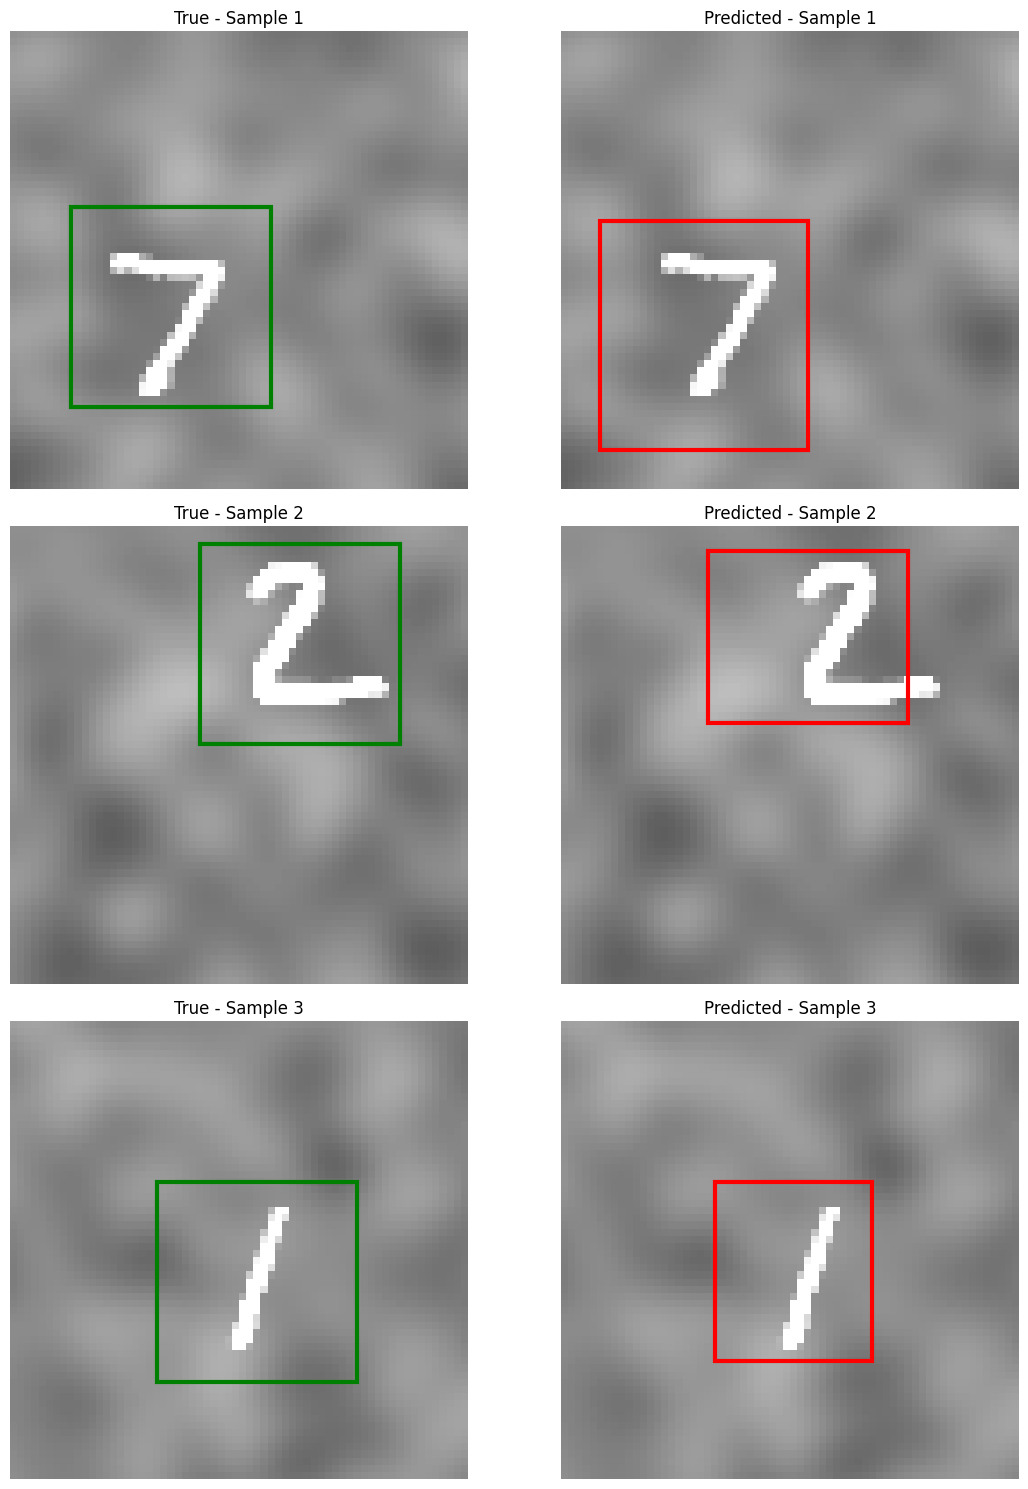

In [16]:
# Тест
print("=== ТЕСТ С ТЕМ ЖЕ РАСЧЕТОМ, ЧТО И В show_prediction ===")
test_pred = model.predict(test_x_new[:3])
visualize_predictions_matching_yours(
    test_x_new[:3], test_y_new[:3], test_pred[:3], num_samples=3
)

### Тестирование модели
Возьмём случайный образец из нашей тестовой выборки и пропустим его через обученную модель. Визуализируем результат предсказания.

**[ЗАДАНИЕ 4]** Позапускайте этот блок и посмотрите, как работает обученая модель на различных тестовых изображениях.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Prediction: 0
Box: (10, 33, 27, 27)


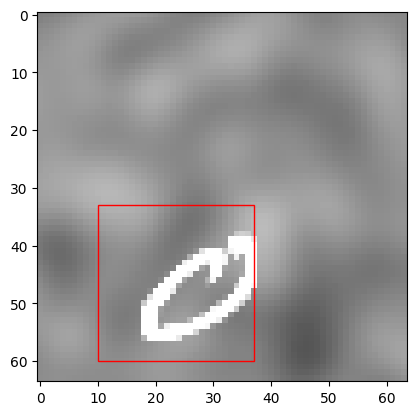

In [20]:
i = random.randint(0, test_x_new.shape[0])
sample = test_x_new[i]

pred = model.predict(sample[None, ...])[0, ...]
show_prediction(sample, pred)

### Дополнительное задание
**[ЗАДАНИЕ 5]** Поэксперементируйте c гипермарамтерами модели и обучения для улучшения качества работы модели. Уделите внимание парамтеру LAMBDA и количеству эпох. Кроме того, попробуйте модифицировать архитектуру нейросети.